**Cast-forged AZ80 Magnesium Microstructure to Mechanical Properties Prediction**

In this notebook, you can use the model trained on a dataset of cast-forged AZ80 magnesium alloys images and their corresponding mechanical properties. The trained model can be tested with Image-Out Validation and Class-Out Validation Scenarios, as well as including any external test image by users. This model is a part of the work published as:
E. Azqadan; A. Arami; H. Jahed, From microstructure to mechanical properties: Image-based machine learning prediction for AZ80 magnesium alloy, J. Magnes. Alloy (2025), https://doi.org/10.1016/j.jma.2025.07.019.

Please cite the paper when using the model. 

**Instruction**

1.  Go to edit mode by clicking "copy and edit" botton.

2. The trained model is already associated with this notebook.

3. You can test your own cast-forged magnesium alloy microstructure images by uploading your image to this notebook using "upload" button under "input" in the right tab. Please place image in a folder and upload the folder to a dataset.

4. From "Input" tab on the right side of the notebook, copy file path for your uploaded image folder and paste it as the address for the "external_validation_dir" variable in the cell below. 

5. Select the image magnification from valid enteries in the cell below and run all cells. 

It is recommended to use accelerator (GPU P100) from notebook options.

In [1]:
external_validation_dir = "/kaggle/input/external2"
#Image magnification {valid enteries: "500", "1000", "1500", or "2000"}
magnification = "500"

In [2]:
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.autograd as autograd
from torch.autograd import Variable
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from numpy.random import randn
import torchvision.utils
from torch.distributions import uniform
from mpl_toolkits.axes_grid1 import ImageGrid
import os
import copy
import csv
from torch.utils.tensorboard import SummaryWriter

In [3]:
image_out_validation_dir = '/kaggle/input/microstructure-to-mechanical-properties/Microstructure-to-Mechanical Properties/Test-Seen'
class_out_validation_dir = '/kaggle/input/microstructure-to-mechanical-properties/Microstructure-to-Mechanical Properties/Test-Unseen'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
image_shape = (1,512,512)
image_size = 512
image_dim = int(np.prod(image_shape))
ys_range = 105
uts_range = 125
el_range = 9.25
e_range = 12
k_range = 250.11
n_range = 0.104
magnifications = 4
embedding_dim = 100
num_classes = 83
learning_rate = 3e-5
check_path = True

mag_dict =  {'100':0, '500':1, '1000':2, '1500':3, '2000':4, '3000':5}


image_out_table = torch.tensor([[    0.000,     0.000,     1.000,     1.000,     3.000,     1.000,
             2.000,     0.000,     1.000,     2.000,     3.000,     0.000,
             1.000,     0.000,     1.000,     0.000,     1.000,     0.000,
             0.000,     1.000,     0.000,     1.000,     3.000,     0.000,
             1.000,     3.000,     0.000,     1.000,     3.000,     0.000,
             1.000,     3.000],
        [  193.000,   212.000,   212.000,   244.000,   244.000,   151.000,
           148.000,   178.000,   178.000,   178.000,   178.000,   177.000,
           177.000,   183.000,   183.000,   202.000,   202.000,   216.000,
           197.000,   197.000,   227.000,   227.000,   227.000,   230.000,
           230.000,   230.000,   183.000,   183.000,   183.000,   216.000,
           216.000,   216.000],
        [  284.000,   289.000,   289.000,   309.000,   309.000,   230.000,
           210.000,   226.000,   226.000,   226.000,   226.000,   299.000,
           299.000,   252.000,   252.000,   280.000,   280.000,   335.000,
           306.000,   306.000,   311.000,   311.000,   311.000,   305.000,
           305.000,   305.000,   299.000,   299.000,   299.000,   307.000,
           307.000,   307.000],
        [    5.750,     4.160,     4.160,     3.170,     3.170,     3.520,
             3.490,     2.130,     2.130,     2.130,     2.130,     4.790,
             4.790,     2.220,     2.220,     4.210,     4.210,     6.900,
            10.010,    10.010,     6.310,     6.310,     6.310,     4.670,
             4.670,     4.670,    10.840,    10.840,    10.840,     7.240,
             7.240,     7.240],
        [   46.000,    46.000,    46.000,    45.000,    45.000,    43.000,
            37.000,    38.000,    38.000,    38.000,    38.000,    47.000,
            47.000,    47.000,    47.000,    40.000,    40.000,    49.000,
            46.000,    46.000,    41.000,    41.000,    41.000,    44.000,
            44.000,    44.000,    46.000,    46.000,    46.000,    45.000,
            45.000,    45.000],
        [  444.060,   450.870,   450.870,   462.380,   462.380,   429.330,
           365.450,   408.530,   408.530,   408.530,   408.530,   552.210,
           552.210,   523.370,   523.370,   450.070,   450.070,   540.690,
           458.930,   458.930,   450.830,   450.830,   450.830,   444.030,
           444.030,   444.030,   454.920,   454.920,   454.920,   448.660,
           448.660,   448.660],
        [    0.130,     0.117,     0.117,     0.096,     0.096,     0.161,
             0.143,     0.130,     0.130,     0.130,     0.130,     0.175,
             0.175,     0.167,     0.167,     0.122,     0.122,     0.148,
             0.132,     0.132,     0.102,     0.102,     0.102,     0.098,
             0.098,     0.098,     0.140,     0.140,     0.140,     0.110,
             0.110,     0.110]])

image_out_label = {
            0: "CM04-0500", 1: "CM10-0500", 2: "CM10-1000", 3: "CM16-1000",
            4: "CM16-2000", 5: "CS01-1000", 6: "CS04-1500", 7: "CS10-0500",
            8: "CS10-1000", 9: "CS10-1500", 10: "CS10-2000", 11: "PL03-0500",
            12: "PL03-1000", 13: "PL13-0500", 14: "PL13-1000", 15: "PL16-0500",
            16: "PL16-1000", 17: "PM03-0500", 18: "PM11-0500", 19: "PM11-1000",
            20: "PM13-0500", 21: "PM13-1000", 22: "PM13-2000", 23: "PM16-0500",
            24: "PM16-1000", 25: "PM16-2000", 26: "PS11-0500",27: "PS11-1000",
            28: "PS11-2000", 29: "PS16-0500", 30: "PS16-1000",31: "PS16-2000"
        }

class_out_table =  torch.tensor([[    0.000,     1.000,     2.000,     3.000,     1.000,     0.000,
             1.000,     2.000,     3.000,     2.000,     0.000,     1.000,
             2.000,     3.000],
        [  223.000,   223.000,   223.000,   223.000,   148.000,   198.000,
           198.000,   198.000,   198.000,   216.000,   208.000,   208.000,
           208.000,   208.000],
        [  302.000,   302.000,   302.000,   302.000,   210.000,   258.000,
           258.000,   258.000,   258.000,   335.000,   311.000,   311.000,
           311.000,   311.000],
        [    4.280,     4.280,     4.280,     4.280,     3.490,     2.750,
             2.750,     2.750,     2.750,     6.900,     6.370,     6.370,
             6.370,     6.370],
        [   43.000,    43.000,    43.000,    43.000,    37.000,    42.000,
            42.000,    42.000,    42.000,    49.000,    38.000,    38.000,
            38.000,    38.000],
        [  466.380,   466.380,   466.380,   466.380,   365.450,   428.760,
           428.760,   428.760,   428.760,   540.690,   485.180,   485.180,
           485.180,   485.180],
        [    0.115,     0.115,     0.115,     0.115,     0.143,     0.120,
             0.120,     0.120,     0.120,     0.148,     0.125,     0.125,
             0.125,     0.125]])

class_out_label = {
    0: 'CM06-500', 1: 'CM06-1000', 2: 'CM06-1500', 3: 'CM06-2000',
    4: 'CS04-1000', 5: 'CS06-0500', 6: 'CS06-1000', 7: 'CS06-1500',
    8: 'CS06-2000', 9: 'PM03-1500', 10: 'PS13-0500', 11: 'PS13-1000',
    12: 'PS13-1500', 13: 'PS13-2000'
}

def process_image(path):
    if not path: 
        raise ValueError("The provided path is empty. Please provide a valid path.")
        
        
    if not os.path.exists(path): 
        raise FileNotFoundError(f"The path '{path}' does not exist.")
        
    
    

try:
    process_image(external_validation_dir)
except:
    print("The provided path is empty or does not exist")
    check_path = False
    
class ConditionalResize:
    def __init__(self):
        self.size = (512,512)
        self.resize_transform = transforms.Resize(self.size)
    
    def __call__(self, image):
        if image.size[0] < self.size[0] or image.size[1] < self.size[1]:
            return self.resize_transform(image)
        return image

conditional_resize = ConditionalResize()
        
test_transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.transforms.RandomCrop(512),
    transforms.ToTensor(),
    transforms.Normalize((0.5),(0.5))
])

external_transform = transforms.Compose([
    transforms.Grayscale(),
    conditional_resize,
    transforms.transforms.RandomCrop(512),
    transforms.ToTensor(),
    transforms.Normalize((0.5),(0.5))
])

aug_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p = 0.5),
    transforms.RandomVerticalFlip(p = 0.5),
    ]) 

if check_path:
    external_test_dataset = datasets.ImageFolder(external_validation_dir, transform = external_transform)
    external_test_loader = torch.utils.data.DataLoader(dataset = external_test_dataset, batch_size = len(external_test_dataset), shuffle = True)
image_out_test_dataset = datasets.ImageFolder(image_out_validation_dir, transform = test_transform)
class_out_test_dataset = datasets.ImageFolder(class_out_validation_dir, transform = test_transform)
image_out_test_loader = torch.utils.data.DataLoader(dataset = image_out_test_dataset, batch_size = 39, shuffle = True)
class_out_test_loader = torch.utils.data.DataLoader(dataset = class_out_test_dataset, batch_size = 33, shuffle = True)

def show_grids(images):
    labels_title = []
    #for i in labels:
    #    labels_title.append(label_dict[i.item()])
    fig = plt.figure(figsize=(2., 2.))
    grid = ImageGrid(fig, 111, 
                     nrows_ncols=(1, 1),  
                     axes_pad=0.0
                     )
    j = 0
    for ax, im in zip(grid, images.cpu().view(-1,image_size,image_size)):
        ax.imshow(im, cmap = 'gray')
        ax.xaxis.set_visible(False)
        ax.yaxis.set_visible(False)
        
        #fig.gca().set_title(labelt[i])
        j += 1
    plt.show()
    #figname = str(0+n_epoch)
    #fig.savefig(figname, bbox_inches='tight')
    plt.close(fig)

def load_model(address):
    checkpoint = torch.load(address, weights_only=True)
    model.load_state_dict(checkpoint["model_state"])
    ema_model.load_state_dict(checkpoint["ema_model_state"])
    optimizer.load_state_dict(checkpoint["model_optimizer"])

def class_maker(batch_size, labels, tab):
   
    Mag = torch.zeros([batch_size])
    YS = torch.zeros([batch_size])
    UTS = torch.zeros([batch_size])
    EL = torch.zeros([batch_size])
    E = torch.zeros([batch_size])
    K = torch.zeros([batch_size])
    N = torch.zeros([batch_size])
    
    for i in range(batch_size):

        Mag[i] = tab[0,labels[i]]
        YS[i] = tab[1,labels[i]]
        UTS[i] = tab[2,labels[i]]
        EL[i] = tab[3,labels[i]]
        E[i] = tab[4,labels[i]]
        K[i] = tab[5,labels[i]]
        N[i] = tab[6,labels[i]]

    return Mag, YS, UTS, EL, E, K, N

def image_error(ys, uts, el, e, k, n, prediction):
    error_ys = abs(ys.item()-prediction[0].item())/ys.item()
    error_uts = abs(uts.item()-prediction[1].item())/uts.item()
    error_el = abs(el.item()-prediction[2].item())/el.item()
    error_e = abs(e.item()-prediction[3].item())/e.item()
    error_k = abs(k.item()-prediction[4].item())/k.item()
    error_n = abs(n.item()-prediction[5].item())/n.item()
    return error_ys, error_uts, error_el, error_e, error_k, error_n

def test(test_data, table):
    test_mean = table[1:,:].mean(dim=1)
    test_std = table[1:,:].std(dim=1)

    test_images, test_labels = next(iter(test_data))
    test_images = aug_transform(test_images)
    test_images = test_images.to(device)
    t_mag, t_ys, t_uts, t_el, t_e, t_k, t_n = class_maker(batch_size = test_labels.size(0), labels = test_labels, tab = table)

    #t_ys = (t_ys - test_mean[0])/test_std[0]
    #t_uts = (t_uts - test_mean[1])/test_std[1]
    #t_el = (t_el - test_mean[2])/test_std[2]
    #t_e = (t_e - test_mean[3])/test_std[3]
    #t_k = (t_k - test_mean[4])/test_std[4]
    #t_n = (t_n - test_mean[5])/test_std[5]
    
    t_mag = t_mag.long().to(device)
    t_ys = t_ys.float().to(device)
    t_uts = t_uts.float().to(device)
    t_el = t_el.float().to(device)
    t_e = t_e.float().to(device)
    t_k = t_k.float().to(device)
    t_n = t_n.float().to(device)
    test_predictions = ema_model(test_images, t_mag)
    test_ys_error = mse(t_ys, test_predictions[:,0])
    test_uts_error = mse(t_uts, test_predictions[:,1])
    test_el_error = mse(t_el, test_predictions[:,2])
    test_e_error = mse(t_e, test_predictions[:,3])
    test_k_error = mse(t_k, test_predictions[:,4])
    test_n_error = mse(t_n, test_predictions[:,5])
    test_total_error = test_ys_error + test_uts_error + test_el_error + test_e_error + test_k_error + test_n_error
    
    return test_ys_error, test_uts_error, test_el_error, test_e_error, test_k_error, test_n_error, test_total_error

class EMA:
    def __init__(self, beta):
        super().__init__()
        self.beta = beta
        self.step = 0
        
    def update_model_average(self, ma_model, current_model):
        for current_params, ma_params in zip(current_model.parameters(), ma_model.parameters()):
            old_weight, up_weight = ma_params.data, current_params.data
            ma_params.data = self.update_average(old_weight, up_weight)
            
    def update_average(self, old, new):
        if old is None:
            return new
        return old*self.beta + (1-self.beta)*new
    
    def step_ema(self, ema_model, model, step_start_ema=0):
        if self.step < step_start_ema:
            self.reset_parameters(ema_model, model)
            self.step += 1
            return
        if self.step == step_start_ema:
            print('EMA started!')
        self.update_model_average(ema_model, model)
        self.step += 1
        
    def reset_parameters(self, ema_model, model):
        ema_model.load_state_dict(model.state_dict())
              
    
        

class SelfAttention(nn.Module):
    def __init__(self, channels, size):
        super(SelfAttention, self).__init__()
        self.channels = channels
        self.size = size
        self.mha = nn.MultiheadAttention(channels, 4, batch_first=True)
        self.ln = nn.LayerNorm([channels])
        self.ff_self = nn.Sequential(
            nn.LayerNorm([channels]),
            nn.Linear(channels, channels),
            nn.GELU(),
            nn.Linear(channels, channels)
        )
        
    def forward(self,x):
        x = x.view(-1, self.channels, self.size*self.size).swapaxes(1,2)
        x_ln = self.ln(x)
        attention_value, _ = self.mha(x_ln, x_ln, x_ln)
        attention_value = attention_value + x
        attention_value = self.ff_self(attention_value) + attention_value
        return attention_value.swapaxes(2,1).view(-1, self.channels, self.size, self.size)
    
    
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, mid_channels = None, residual = False):
        super().__init__()
        self.residual = residual
        if not mid_channels:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(1, mid_channels),
            nn.GELU(),
            nn.Conv2d(mid_channels, out_channels,kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(1, out_channels)
        )
    
    def forward(self, x):
        if self.residual:
            return F.gelu(x + self.double_conv(x))
        else:
            return self.double_conv(x)
        
        
class Down(nn.Module):
    def __init__(self, in_channels, out_channels, imsize, emb_dim=512):
        super().__init__()
        self.imsize = imsize
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, in_channels, residual=True),
            DoubleConv(in_channels, (out_channels-1))
        )


        self.Mag_label = nn.Sequential(
                                nn.Embedding(magnifications, embedding_dim),
                                nn.Linear(embedding_dim, 1*self.imsize*self.imsize))
        
    def forward(self, x, Mag):
        x = self.maxpool_conv(x)
        magemb = self.Mag_label(Mag).view(x.shape[0],1,x.shape[-2],x.shape[-1])
        x = torch.cat((x, magemb), dim = 1)
        return x

    
class Dense(nn.Module):
    def __init__(self, in_channels, mid_channels):
        super().__init__()
        self.linear = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_channels, mid_channels),
            nn.LeakyReLU(0.2, inplace = True),
            nn.Dropout(0.25),
            nn.Linear(mid_channels, 6),
            nn.LeakyReLU(0.2, inplace = True)
        ) 
        
    def forward(self, x):
        x = self.linear(x)
        return x

class Net_conditional(nn.Module):
    def __init__(self,c_in = 1, num_classes=None):
        super().__init__()
        self.inc = DoubleConv(c_in, 16)
        self.down1 = Down(16,32, 256)
        self.sa1 = SelfAttention(32, 256)
        self.down2 = Down(32, 64, 128)
        self.sa2 = SelfAttention(64, 128)
        self.down3 = Down(64, 128, 64)
        self.sa3 = SelfAttention(128, 64)
        self.down4 = Down(128, 256, 32)
        self.sa4 = SelfAttention(256, 32)
        self.down5 = Down(256, 512, 16)
        self.sa5 = SelfAttention(512, 16)
        self.down6 = Down(512, 512, 8)
        self.sa6 = SelfAttention(512, 8)
        
        self.bot1 = DoubleConv(512, 256)
        self.bot2 = DoubleConv(256, 128)
        self.bot3 = DoubleConv(128, 64)
        
        self.linear = Dense(64*8*8, 64*8*8*2)
        
    
    def forward(self, x, Mag):
                    
        x = self.inc(x)
        x = self.down1(x, Mag)
        #x = self.sa1(x)
        x = self.down2(x, Mag)
        #x = self.sa2(x)
        x = self.down3(x, Mag)
        #x = self.sa3(x)
        x = self.down4(x, Mag)
        x = self.sa4(x)
        x = self.down5(x, Mag)
        x = self.sa5(x)
        x = self.down6(x, Mag)
        x = self.sa6(x)
        
        x = self.bot1(x)
        x = self.bot2(x)
        x = self.bot3(x)
        
        x = self.linear(x)
        
        
        
        return x
    
model = Net_conditional(num_classes = num_classes).to(device)
optimizer = optim.Adam(model.parameters(), lr = learning_rate)
mse = nn.MSELoss()
ema = EMA(0.995)
ema_model = copy.deepcopy(model).eval().requires_grad_(False)

The provided path is empty or does not exist


In [4]:
#External Validation
if check_path:
    load_dir = '/kaggle/input/mic-mech3-checkpoint/Mic-Mech-Over-Best800.pth.tar'
    load_model(load_dir)
    model.eval()
    with torch.no_grad(): 
        test_iter = next(iter(external_test_loader))
        test_images, test_labels = test_iter
        test_images = aug_transform(test_images)
        test_images = test_images.to(device)
        external_magnification = torch.tensor([mag_dict[magnification]])
        t_mag = external_magnification.long().to(device)
        test_predictions = ema_model(test_images, t_mag)
        original_test_predictions = test_predictions
        show_grids(test_images[0])
        print(f'YS Prediction: {original_test_predictions[0,0]}')
        print(f'UTS Prediction: {original_test_predictions[0,1]}')
        print(f'E Prediction: {original_test_predictions[0,3]}')
        print(f'k Prediction: {original_test_predictions[0,4]}')
        print(f'n Prediction: {original_test_predictions[0,5]}')
else:
    print("Upload image to predict its mechanical properties")

Upload image to predict its mechanical properties


Image-Out Validation


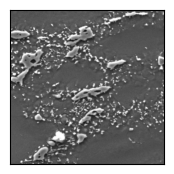

PM16-1000
YS Prediction: 229.90025329589844 ; YS Target: 230.0 ; YS Error%: 0.0433681346476078
UTS Prediction: 303.0766296386719 ; UTS Target: 305.0 ; UTS Error%: 0.6306132078170776 
E Prediction: 43.54823303222656 ; E Target: 44.0 ; E Error%: 1.0267430543899536 
k Prediction: 444.31121826171875 ; k Target: 444.0299987792969 ; k Error%: 0.06333344429731369 
n Prediction: 0.09196478128433228 ; n Target: 0.09799999743700027 ; n Error%: 6.158383846282959 
---------------------------------------------


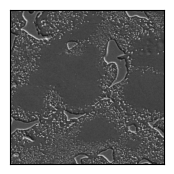

CS10-0500
YS Prediction: 177.2897491455078 ; YS Target: 178.0 ; YS Error%: 0.399017333984375
UTS Prediction: 225.63272094726562 ; UTS Target: 226.0 ; UTS Error%: 0.1625128537416458 
E Prediction: 38.01422119140625 ; E Target: 38.0 ; E Error%: 0.03742418810725212 
k Prediction: 408.7584228515625 ; k Target: 408.5299987792969 ; k Error%: 0.05591366067528725 
n Prediction: 0.13268311321735382 ; n Target: 0.12999999523162842 ; n Error%: 2.063936948776245 
---------------------------------------------


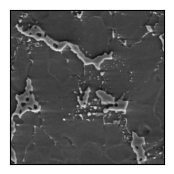

CS01-1000
YS Prediction: 155.74130249023438 ; YS Target: 151.0 ; YS Error%: 3.1399354934692383
UTS Prediction: 236.04823303222656 ; UTS Target: 230.0 ; UTS Error%: 2.629666566848755 
E Prediction: 43.220603942871094 ; E Target: 43.0 ; E Error%: 0.5130323767662048 
k Prediction: 440.41796875 ; k Target: 429.3299865722656 ; k Error%: 2.582624673843384 
n Prediction: 0.16556240618228912 ; n Target: 0.16099999845027924 ; n Error%: 2.8337936401367188 
---------------------------------------------


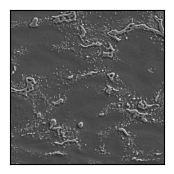

PM13-0500
YS Prediction: 228.84059143066406 ; YS Target: 227.0 ; YS Error%: 0.8108332753181458
UTS Prediction: 309.6689147949219 ; UTS Target: 311.0 ; UTS Error%: 0.42800167202949524 
E Prediction: 41.64962387084961 ; E Target: 41.0 ; E Error%: 1.5844484567642212 
k Prediction: 447.9916687011719 ; k Target: 450.8299865722656 ; k Error%: 0.6295760869979858 
n Prediction: 0.09788188338279724 ; n Target: 0.10199999809265137 ; n Error%: 4.037367343902588 
---------------------------------------------


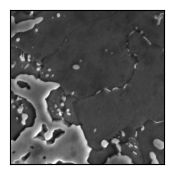

PS11-2000
YS Prediction: 179.6753692626953 ; YS Target: 183.0 ; YS Error%: 1.8167380094528198
UTS Prediction: 295.541748046875 ; UTS Target: 299.0 ; UTS Error%: 1.1566059589385986 
E Prediction: 46.01622009277344 ; E Target: 46.0 ; E Error%: 0.03526107221841812 
k Prediction: 454.2762756347656 ; k Target: 454.9200134277344 ; k Error%: 0.14150571823120117 
n Prediction: 0.14487290382385254 ; n Target: 0.14000000059604645 ; n Error%: 3.480645179748535 
---------------------------------------------


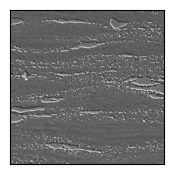

CM10-0500
YS Prediction: 212.257568359375 ; YS Target: 212.0 ; YS Error%: 0.12149450927972794
UTS Prediction: 289.8893737792969 ; UTS Target: 289.0 ; UTS Error%: 0.30774179100990295 
E Prediction: 46.07464599609375 ; E Target: 46.0 ; E Error%: 0.16227389872074127 
k Prediction: 452.5335388183594 ; k Target: 450.8699951171875 ; k Error%: 0.3689630329608917 
n Prediction: 0.12179842591285706 ; n Target: 0.11699999868869781 ; n Error%: 4.101219654083252 
---------------------------------------------


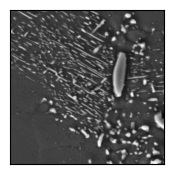

CS10-2000
YS Prediction: 178.51931762695312 ; YS Target: 178.0 ; YS Error%: 0.2917514741420746
UTS Prediction: 227.4917755126953 ; UTS Target: 226.0 ; UTS Error%: 0.660077691078186 
E Prediction: 38.124366760253906 ; E Target: 38.0 ; E Error%: 0.3272809684276581 
k Prediction: 410.3192138671875 ; k Target: 408.5299987792969 ; k Error%: 0.43796417117118835 
n Prediction: 0.12872540950775146 ; n Target: 0.12999999523162842 ; n Error%: 0.9804505705833435 
---------------------------------------------


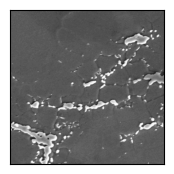

PM11-1000
YS Prediction: 197.3523406982422 ; YS Target: 197.0 ; YS Error%: 0.1788531392812729
UTS Prediction: 305.9132995605469 ; UTS Target: 306.0 ; UTS Error%: 0.028333477675914764 
E Prediction: 46.00476837158203 ; E Target: 46.0 ; E Error%: 0.010366025380790234 
k Prediction: 456.9359130859375 ; k Target: 458.92999267578125 ; k Error%: 0.43450626730918884 
n Prediction: 0.13343249261379242 ; n Target: 0.13199999928474426 ; n Error%: 1.0852222442626953 
---------------------------------------------


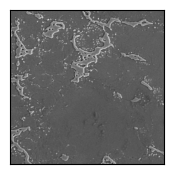

PS11-0500
YS Prediction: 183.3081512451172 ; YS Target: 183.0 ; YS Error%: 0.16838866472244263
UTS Prediction: 295.2994384765625 ; UTS Target: 299.0 ; UTS Error%: 1.2376459836959839 
E Prediction: 45.53713607788086 ; E Target: 46.0 ; E Error%: 1.0062259435653687 
k Prediction: 450.1451416015625 ; k Target: 454.9200134277344 ; k Error%: 1.0496069192886353 
n Prediction: 0.13789966702461243 ; n Target: 0.14000000059604645 ; n Error%: 1.500238299369812 
---------------------------------------------


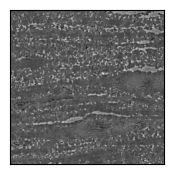

CM16-1000
YS Prediction: 244.67141723632812 ; YS Target: 244.0 ; YS Error%: 0.2751709818840027
UTS Prediction: 310.9876403808594 ; UTS Target: 309.0 ; UTS Error%: 0.6432493329048157 
E Prediction: 45.06093978881836 ; E Target: 45.0 ; E Error%: 0.1354217529296875 
k Prediction: 463.1876220703125 ; k Target: 462.3800048828125 ; k Error%: 0.17466525733470917 
n Prediction: 0.08462291955947876 ; n Target: 0.09600000083446503 ; n Error%: 11.851125717163086 
---------------------------------------------


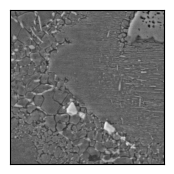

CM16-2000
YS Prediction: 242.38096618652344 ; YS Target: 244.0 ; YS Error%: 0.6635384559631348
UTS Prediction: 308.41046142578125 ; UTS Target: 309.0 ; UTS Error%: 0.19078917801380157 
E Prediction: 44.97090530395508 ; E Target: 45.0 ; E Error%: 0.0646548792719841 
k Prediction: 463.0829162597656 ; k Target: 462.3800048828125 ; k Error%: 0.15202029049396515 
n Prediction: 0.08608882874250412 ; n Target: 0.09600000083446503 ; n Error%: 10.324137687683105 
---------------------------------------------


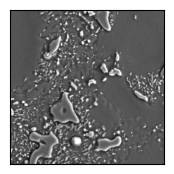

PL13-1000
YS Prediction: 179.33555603027344 ; YS Target: 183.0 ; YS Error%: 2.0024285316467285
UTS Prediction: 251.1909637451172 ; UTS Target: 252.0 ; UTS Error%: 0.3210461139678955 
E Prediction: 47.483497619628906 ; E Target: 47.0 ; E Error%: 1.02871835231781 
k Prediction: 534.6519165039062 ; k Target: 523.3699951171875 ; k Error%: 2.155630111694336 
n Prediction: 0.1760769486427307 ; n Target: 0.16699999570846558 ; n Error%: 5.435301303863525 
---------------------------------------------


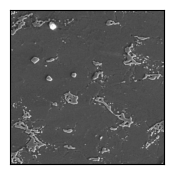

PM11-0500
YS Prediction: 196.40652465820312 ; YS Target: 197.0 ; YS Error%: 0.3012565076351166
UTS Prediction: 305.9797668457031 ; UTS Target: 306.0 ; UTS Error%: 0.0066121420823037624 
E Prediction: 45.97780990600586 ; E Target: 46.0 ; E Error%: 0.0482393354177475 
k Prediction: 457.773193359375 ; k Target: 458.92999267578125 ; k Error%: 0.25206443667411804 
n Prediction: 0.13301272690296173 ; n Target: 0.13199999928474426 ; n Error%: 0.7672178745269775 
---------------------------------------------


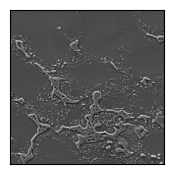

PS16-0500
YS Prediction: 217.4612274169922 ; YS Target: 216.0 ; YS Error%: 0.6764941811561584
UTS Prediction: 302.83172607421875 ; UTS Target: 307.0 ; UTS Error%: 1.3577439785003662 
E Prediction: 44.71635055541992 ; E Target: 45.0 ; E Error%: 0.6303321123123169 
k Prediction: 448.3745422363281 ; k Target: 448.6600036621094 ; k Error%: 0.06362533569335938 
n Prediction: 0.11636895686388016 ; n Target: 0.10999999940395355 ; n Error%: 5.789961338043213 
---------------------------------------------


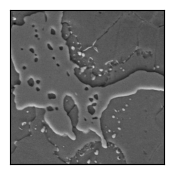

CS04-1500
YS Prediction: 160.72425842285156 ; YS Target: 148.0 ; YS Error%: 8.597471237182617
UTS Prediction: 244.42950439453125 ; UTS Target: 210.0 ; UTS Error%: 16.395002365112305 
E Prediction: 43.468936920166016 ; E Target: 37.0 ; E Error%: 17.483612060546875 
k Prediction: 424.0458984375 ; k Target: 365.45001220703125 ; k Error%: 16.033899307250977 
n Prediction: 0.15995419025421143 ; n Target: 0.14300000667572021 ; n Error%: 11.856071472167969 
---------------------------------------------


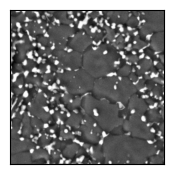

CS10-2000
YS Prediction: 195.47076416015625 ; YS Target: 178.0 ; YS Error%: 9.815035820007324
UTS Prediction: 269.14508056640625 ; UTS Target: 226.0 ; UTS Error%: 19.090744018554688 
E Prediction: 39.78041458129883 ; E Target: 38.0 ; E Error%: 4.685301780700684 
k Prediction: 439.2978820800781 ; k Target: 408.5299987792969 ; k Error%: 7.531364440917969 
n Prediction: 0.12340418994426727 ; n Target: 0.12999999523162842 ; n Error%: 5.073696136474609 
---------------------------------------------


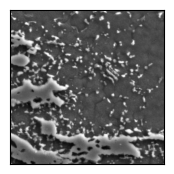

PM13-2000
YS Prediction: 230.42855834960938 ; YS Target: 227.0 ; YS Error%: 1.510378122329712
UTS Prediction: 303.7996520996094 ; UTS Target: 311.0 ; UTS Error%: 2.3152244091033936 
E Prediction: 43.540836334228516 ; E Target: 41.0 ; E Error%: 6.19716215133667 
k Prediction: 443.39703369140625 ; k Target: 450.8299865722656 ; k Error%: 1.6487263441085815 
n Prediction: 0.09234876930713654 ; n Target: 0.10199999809265137 ; n Error%: 9.461989402770996 
---------------------------------------------


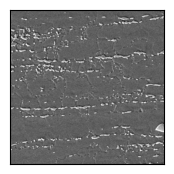

CM04-0500
YS Prediction: 201.5165252685547 ; YS Target: 193.0 ; YS Error%: 4.412707328796387
UTS Prediction: 289.0729064941406 ; UTS Target: 284.0 ; UTS Error%: 1.7862346172332764 
E Prediction: 45.284881591796875 ; E Target: 46.0 ; E Error%: 1.55460524559021 
k Prediction: 444.7186584472656 ; k Target: 444.05999755859375 ; k Error%: 0.14832700788974762 
n Prediction: 0.12381743639707565 ; n Target: 0.12999999523162842 ; n Error%: 4.755814552307129 
---------------------------------------------


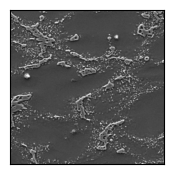

PM16-0500
YS Prediction: 229.79208374023438 ; YS Target: 230.0 ; YS Error%: 0.09039837121963501
UTS Prediction: 304.81317138671875 ; UTS Target: 305.0 ; UTS Error%: 0.061255279928445816 
E Prediction: 43.34428787231445 ; E Target: 44.0 ; E Error%: 1.4902547597885132 
k Prediction: 444.3782653808594 ; k Target: 444.0299987792969 ; k Error%: 0.07843312621116638 
n Prediction: 0.09409131109714508 ; n Target: 0.09799999743700027 ; n Error%: 3.9884555339813232 
---------------------------------------------


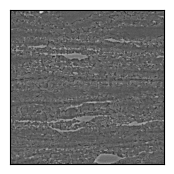

CM16-1000
YS Prediction: 247.6602325439453 ; YS Target: 244.0 ; YS Error%: 1.5000953674316406
UTS Prediction: 322.2996520996094 ; UTS Target: 309.0 ; UTS Error%: 4.3040947914123535 
E Prediction: 43.49156951904297 ; E Target: 45.0 ; E Error%: 3.352067708969116 
k Prediction: 468.49615478515625 ; k Target: 462.3800048828125 ; k Error%: 1.3227540254592896 
n Prediction: 0.08460461348295212 ; n Target: 0.09600000083446503 ; n Error%: 11.870195388793945 
---------------------------------------------


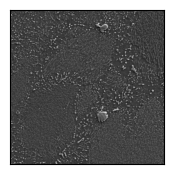

PM03-0500
YS Prediction: 208.18263244628906 ; YS Target: 216.0 ; YS Error%: 3.6191515922546387
UTS Prediction: 330.85595703125 ; UTS Target: 335.0 ; UTS Error%: 1.2370277643203735 
E Prediction: 48.229705810546875 ; E Target: 49.0 ; E Error%: 1.5720288753509521 
k Prediction: 545.35107421875 ; k Target: 540.6900024414062 ; k Error%: 0.8620599508285522 
n Prediction: 0.15740743279457092 ; n Target: 0.14800000190734863 ; n Error%: 6.356371879577637 
---------------------------------------------


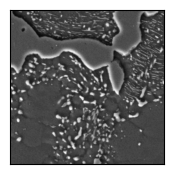

CS10-1500
YS Prediction: 177.0255584716797 ; YS Target: 178.0 ; YS Error%: 0.5474390387535095
UTS Prediction: 226.64776611328125 ; UTS Target: 226.0 ; UTS Error%: 0.28662219643592834 
E Prediction: 38.145111083984375 ; E Target: 38.0 ; E Error%: 0.3818712532520294 
k Prediction: 409.8399658203125 ; k Target: 408.5299987792969 ; k Error%: 0.3206538259983063 
n Prediction: 0.13444064557552338 ; n Target: 0.12999999523162842 ; n Error%: 3.4158847332000732 
---------------------------------------------


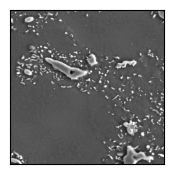

PL16-1000
YS Prediction: 227.15478515625 ; YS Target: 202.0 ; YS Error%: 12.452863693237305
UTS Prediction: 303.83319091796875 ; UTS Target: 280.0 ; UTS Error%: 8.51185417175293 
E Prediction: 43.726165771484375 ; E Target: 40.0 ; E Error%: 9.315414428710938 
k Prediction: 445.8252258300781 ; k Target: 450.07000732421875 ; k Error%: 0.943138062953949 
n Prediction: 0.10014937818050385 ; n Target: 0.12200000137090683 ; n Error%: 17.91034698486328 
---------------------------------------------


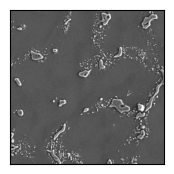

PL16-0500
YS Prediction: 199.94920349121094 ; YS Target: 202.0 ; YS Error%: 1.015245795249939
UTS Prediction: 276.1702880859375 ; UTS Target: 280.0 ; UTS Error%: 1.3677542209625244 
E Prediction: 41.838523864746094 ; E Target: 40.0 ; E Error%: 4.596309661865234 
k Prediction: 472.2664489746094 ; k Target: 450.07000732421875 ; k Error%: 4.9317755699157715 
n Prediction: 0.1248842403292656 ; n Target: 0.12200000137090683 ; n Error%: 2.3641302585601807 
---------------------------------------------


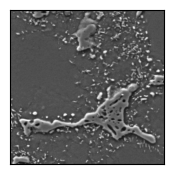

PS16-1000
YS Prediction: 217.38182067871094 ; YS Target: 216.0 ; YS Error%: 0.6397318243980408
UTS Prediction: 307.15924072265625 ; UTS Target: 307.0 ; UTS Error%: 0.051869940012693405 
E Prediction: 44.20037078857422 ; E Target: 45.0 ; E Error%: 1.7769538164138794 
k Prediction: 451.388671875 ; k Target: 448.6600036621094 ; k Error%: 0.6081817150115967 
n Prediction: 0.11842265725135803 ; n Target: 0.10999999940395355 ; n Error%: 7.656961441040039 
---------------------------------------------


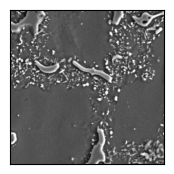

PL13-1000
YS Prediction: 186.96751403808594 ; YS Target: 183.0 ; YS Error%: 2.1680405139923096
UTS Prediction: 248.41664123535156 ; UTS Target: 252.0 ; UTS Error%: 1.4219677448272705 
E Prediction: 42.58876419067383 ; E Target: 47.0 ; E Error%: 9.385607719421387 
k Prediction: 468.3006591796875 ; k Target: 523.3699951171875 ; k Error%: 10.522066116333008 
n Prediction: 0.14670920372009277 ; n Target: 0.16699999570846558 ; n Error%: 12.150175094604492 
---------------------------------------------


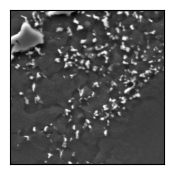

PM16-2000
YS Prediction: 198.86099243164062 ; YS Target: 230.0 ; YS Error%: 13.53869915008545
UTS Prediction: 274.1548767089844 ; UTS Target: 305.0 ; UTS Error%: 10.113155364990234 
E Prediction: 40.21311950683594 ; E Target: 44.0 ; E Error%: 8.606546401977539 
k Prediction: 443.84613037109375 ; k Target: 444.0299987792969 ; k Error%: 0.04140900447964668 
n Prediction: 0.11846771091222763 ; n Target: 0.09799999743700027 ; n Error%: 20.88542366027832 
---------------------------------------------


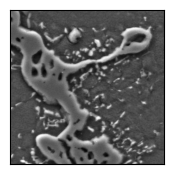

PS16-2000
YS Prediction: 218.27438354492188 ; YS Target: 216.0 ; YS Error%: 1.0529553890228271
UTS Prediction: 305.2635498046875 ; UTS Target: 307.0 ; UTS Error%: 0.5656189918518066 
E Prediction: 42.38440704345703 ; E Target: 45.0 ; E Error%: 5.812428951263428 
k Prediction: 452.4681396484375 ; k Target: 448.6600036621094 ; k Error%: 0.8487799167633057 
n Prediction: 0.12082754820585251 ; n Target: 0.10999999940395355 ; n Error%: 9.843226432800293 
---------------------------------------------


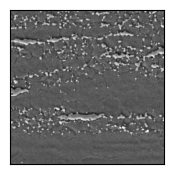

CM10-1000
YS Prediction: 212.77426147460938 ; YS Target: 212.0 ; YS Error%: 0.3652176856994629
UTS Prediction: 288.4817199707031 ; UTS Target: 289.0 ; UTS Error%: 0.17933565378189087 
E Prediction: 46.1395263671875 ; E Target: 46.0 ; E Error%: 0.30331820249557495 
k Prediction: 450.2071228027344 ; k Target: 450.8699951171875 ; k Error%: 0.14702072739601135 
n Prediction: 0.12089937925338745 ; n Target: 0.11699999868869781 ; n Error%: 3.332803726196289 
---------------------------------------------


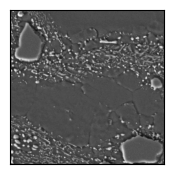

CS10-1000
YS Prediction: 176.13133239746094 ; YS Target: 178.0 ; YS Error%: 1.0498132705688477
UTS Prediction: 224.7422332763672 ; UTS Target: 226.0 ; UTS Error%: 0.5565339922904968 
E Prediction: 37.93843078613281 ; E Target: 38.0 ; E Error%: 0.16202424466609955 
k Prediction: 405.4121398925781 ; k Target: 408.5299987792969 ; k Error%: 0.7631896734237671 
n Prediction: 0.1311318725347519 ; n Target: 0.12999999523162842 ; n Error%: 0.8706748485565186 
---------------------------------------------


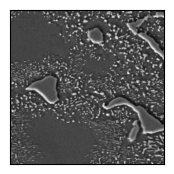

CS10-1000
YS Prediction: 178.0059051513672 ; YS Target: 178.0 ; YS Error%: 0.0033175009302794933
UTS Prediction: 226.22019958496094 ; UTS Target: 226.0 ; UTS Error%: 0.09743344038724899 
E Prediction: 38.07670593261719 ; E Target: 38.0 ; E Error%: 0.20185771584510803 
k Prediction: 409.2608642578125 ; k Target: 408.5299987792969 ; k Error%: 0.1789012998342514 
n Prediction: 0.13136276602745056 ; n Target: 0.12999999523162842 ; n Error%: 1.0482852458953857 
---------------------------------------------


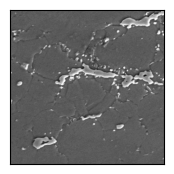

PM11-1000
YS Prediction: 197.25289916992188 ; YS Target: 197.0 ; YS Error%: 0.12837521731853485
UTS Prediction: 307.05499267578125 ; UTS Target: 306.0 ; UTS Error%: 0.34476885199546814 
E Prediction: 46.02339553833008 ; E Target: 46.0 ; E Error%: 0.05085986480116844 
k Prediction: 458.48388671875 ; k Target: 458.92999267578125 ; k Error%: 0.09720566123723984 
n Prediction: 0.13482163846492767 ; n Target: 0.13199999928474426 ; n Error%: 2.1376054286956787 
---------------------------------------------


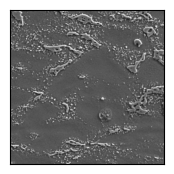

PM13-0500
YS Prediction: 229.20819091796875 ; YS Target: 227.0 ; YS Error%: 0.9727713465690613
UTS Prediction: 311.1623840332031 ; UTS Target: 311.0 ; UTS Error%: 0.05221351608633995 
E Prediction: 41.06761932373047 ; E Target: 41.0 ; E Error%: 0.16492517292499542 
k Prediction: 449.31201171875 ; k Target: 450.8299865722656 ; k Error%: 0.3367066979408264 
n Prediction: 0.09907685965299606 ; n Target: 0.10199999809265137 ; n Error%: 2.8658220767974854 
---------------------------------------------


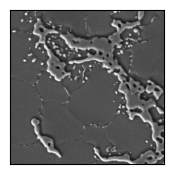

CS01-1000
YS Prediction: 153.4003448486328 ; YS Target: 151.0 ; YS Error%: 1.5896323919296265
UTS Prediction: 230.6273956298828 ; UTS Target: 230.0 ; UTS Error%: 0.27278071641921997 
E Prediction: 42.78256607055664 ; E Target: 43.0 ; E Error%: 0.5056602954864502 
k Prediction: 426.456298828125 ; k Target: 429.3299865722656 ; k Error%: 0.6693423986434937 
n Prediction: 0.16076181828975677 ; n Target: 0.16099999845027924 ; n Error%: 0.14793799817562103 
---------------------------------------------


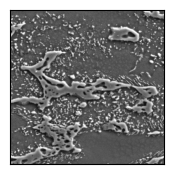

PM13-1000
YS Prediction: 228.64866638183594 ; YS Target: 227.0 ; YS Error%: 0.7262847423553467
UTS Prediction: 309.46270751953125 ; UTS Target: 311.0 ; UTS Error%: 0.4943062663078308 
E Prediction: 41.55792236328125 ; E Target: 41.0 ; E Error%: 1.3607861995697021 
k Prediction: 448.0990905761719 ; k Target: 450.8299865722656 ; k Error%: 0.6057485342025757 
n Prediction: 0.09824193269014359 ; n Target: 0.10199999809265137 ; n Error%: 3.684378147125244 
---------------------------------------------


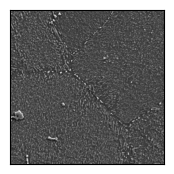

PL03-0500
YS Prediction: 177.30311584472656 ; YS Target: 177.0 ; YS Error%: 0.17125189304351807
UTS Prediction: 298.3243408203125 ; UTS Target: 299.0 ; UTS Error%: 0.2259729653596878 
E Prediction: 47.10083770751953 ; E Target: 47.0 ; E Error%: 0.21454831957817078 
k Prediction: 551.4931640625 ; k Target: 552.2100219726562 ; k Error%: 0.1298161745071411 
n Prediction: 0.16929768025875092 ; n Target: 0.17499999701976776 ; n Error%: 3.2584667205810547 
---------------------------------------------


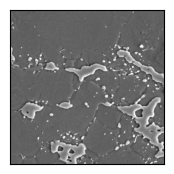

PS11-1000
YS Prediction: 192.6343536376953 ; YS Target: 183.0 ; YS Error%: 5.264674186706543
UTS Prediction: 304.116943359375 ; UTS Target: 299.0 ; UTS Error%: 1.7113523483276367 
E Prediction: 46.16512680053711 ; E Target: 46.0 ; E Error%: 0.3589712977409363 
k Prediction: 457.2010803222656 ; k Target: 454.9200134277344 ; k Error%: 0.5014215111732483 
n Prediction: 0.13800568878650665 ; n Target: 0.14000000059604645 ; n Error%: 1.4245084524154663 
---------------------------------------------


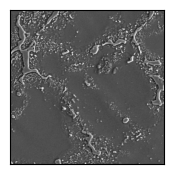

PL13-0500
YS Prediction: 185.78738403320312 ; YS Target: 183.0 ; YS Error%: 1.523160696029663
UTS Prediction: 258.05316162109375 ; UTS Target: 252.0 ; UTS Error%: 2.402048110961914 
E Prediction: 46.32891845703125 ; E Target: 47.0 ; E Error%: 1.427833080291748 
k Prediction: 515.0242919921875 ; k Target: 523.3699951171875 ; k Error%: 1.5946086645126343 
n Prediction: 0.16076290607452393 ; n Target: 0.16699999570846558 ; n Error%: 3.7347841262817383 
---------------------------------------------


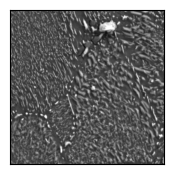

PL03-1000
YS Prediction: 177.5180206298828 ; YS Target: 177.0 ; YS Error%: 0.292667031288147
UTS Prediction: 298.5633850097656 ; UTS Target: 299.0 ; UTS Error%: 0.14602507650852203 
E Prediction: 47.07358169555664 ; E Target: 47.0 ; E Error%: 0.15655680000782013 
k Prediction: 550.8259887695312 ; k Target: 552.2100219726562 ; k Error%: 0.2506352961063385 
n Prediction: 0.1687651425600052 ; n Target: 0.17499999701976776 ; n Error%: 3.562774181365967 
---------------------------------------------
avg YS error: 2.152221441268921
avg UTS error: 2.1474833488464355
avg K error: 1.5302096605300903
avg n error: 5.488867282867432


In [5]:
#Image-Out Validation
print("Image-Out Validation")
load_dir = '/kaggle/input/mic-mech3-checkpoint/Mic-Mech-Over-Best800.pth.tar'
load_model(load_dir)
model.eval()
with torch.no_grad():    
        
        test_iter = next(iter(image_out_test_loader))
        test_images, test_labels = test_iter
        test_images = aug_transform(test_images)
        test_images = test_images.to(device)
        t_mag, t_ys, t_uts, t_el, t_e, t_k, t_n = class_maker(batch_size = test_labels.size(0), labels = test_labels, tab = image_out_table)
        t_mag = t_mag.long().to(device)

        t_ys = t_ys.float().to(device)
        t_uts = t_uts.float().to(device)
        t_el = t_el.float().to(device)
        t_e = t_e.float().to(device)
        t_k = t_k.float().to(device)
        t_n = t_n.float().to(device)
        test_predictions = ema_model(test_images, t_mag)
        original_test_predictions =  test_predictions
    
        summY = 0
        summU = 0
        summK = 0
        summN = 0
        for i in range(len(test_images)):
            show_grids(test_images[i])
            print(image_out_label[test_labels[i].item()])
            print(f'YS Prediction: {original_test_predictions[i,0]} ; YS Target: {t_ys[i]} ; YS Error%: {(abs(original_test_predictions[i,0]-t_ys[i])/t_ys[i])*100}' )
            summY += (abs(original_test_predictions[i,0]-t_ys[i])/t_ys[i])*100
            summU += (abs(original_test_predictions[i,1]-t_uts[i])/t_uts[i])*100
            summK += (abs(original_test_predictions[i,4]-t_k[i])/t_k[i])*100 
            summN += (abs(original_test_predictions[i,5]-t_n[i])/t_n[i])*100 
            print(f'UTS Prediction: {original_test_predictions[i,1]} ; UTS Target: {t_uts[i]} ; UTS Error%: {(abs(original_test_predictions[i,1]-t_uts[i])/t_uts[i])*100} ')
            print(f'E Prediction: {original_test_predictions[i,3]} ; E Target: {t_e[i]} ; E Error%: {(abs(original_test_predictions[i,3]-t_e[i])/t_e[i])*100} ')
            print(f'k Prediction: {original_test_predictions[i,4]} ; k Target: {t_k[i]} ; k Error%: {(abs(original_test_predictions[i,4]-t_k[i])/t_k[i])*100} ')
            print(f'n Prediction: {original_test_predictions[i,5]} ; n Target: {t_n[i]} ; n Error%: {(abs(original_test_predictions[i,5]-t_n[i])/t_n[i])*100} ')
            print('---------------------------------------------')
print(f'avg YS error: {summY/len(test_images)}')
print(f'avg UTS error: {summU/len(test_images)}')
print(f'avg K error: {summK/len(test_images)}')
print(f'avg n error: {summN/len(test_images)}')

Class-Out Validation


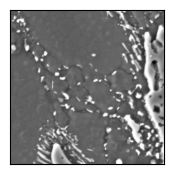

PS13-2000
YS Prediction: 201.0772705078125 ; YS Target: 208.0 ; YS Error%: 3.328235387802124
UTS Prediction: 280.8898620605469 ; UTS Target: 311.0 ; UTS Error%: 9.681716918945312 
E Prediction: 40.71260452270508 ; E Target: 38.0 ; E Error%: 7.138433456420898 
k Prediction: 449.53729248046875 ; k Target: 485.17999267578125 ; k Error%: 7.346283435821533 
n Prediction: 0.11973466724157333 ; n Target: 0.125 ; n Error%: 4.212265968322754 
---------------------------------------------


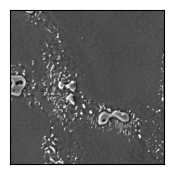

PS13-1000
YS Prediction: 192.93734741210938 ; YS Target: 208.0 ; YS Error%: 7.241659641265869
UTS Prediction: 270.08831787109375 ; UTS Target: 311.0 ; UTS Error%: 13.154882431030273 
E Prediction: 43.36995315551758 ; E Target: 38.0 ; E Error%: 14.131455421447754 
k Prediction: 476.2788391113281 ; k Target: 485.17999267578125 ; k Error%: 1.834608554840088 
n Prediction: 0.1402510553598404 ; n Target: 0.125 ; n Error%: 12.200843811035156 
---------------------------------------------


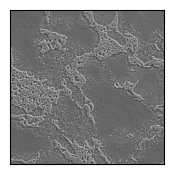

CS06-0500
YS Prediction: 205.73886108398438 ; YS Target: 198.0 ; YS Error%: 3.908515691757202
UTS Prediction: 294.7287902832031 ; UTS Target: 258.0 ; UTS Error%: 14.235965728759766 
E Prediction: 42.77116394042969 ; E Target: 42.0 ; E Error%: 1.8361046314239502 
k Prediction: 464.4969482421875 ; k Target: 428.760009765625 ; k Error%: 8.334951400756836 
n Prediction: 0.1315135955810547 ; n Target: 0.11999999731779099 ; n Error%: 9.59466552734375 
---------------------------------------------


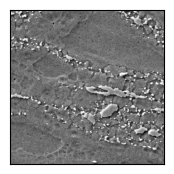

CM06-1000
YS Prediction: 241.04539489746094 ; YS Target: 223.0 ; YS Error%: 8.092105865478516
UTS Prediction: 306.9177551269531 ; UTS Target: 302.0 ; UTS Error%: 1.628395676612854 
E Prediction: 45.5015983581543 ; E Target: 43.0 ; E Error%: 5.817670822143555 
k Prediction: 460.2469177246094 ; k Target: 466.3800048828125 ; k Error%: 1.3150408267974854 
n Prediction: 0.08961475640535355 ; n Target: 0.11500000208616257 ; n Error%: 22.074125289916992 
---------------------------------------------


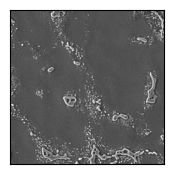

PS13-0500
YS Prediction: 198.53976440429688 ; YS Target: 208.0 ; YS Error%: 4.548190116882324
UTS Prediction: 281.7481994628906 ; UTS Target: 311.0 ; UTS Error%: 9.405723571777344 
E Prediction: 41.40767288208008 ; E Target: 38.0 ; E Error%: 8.967560768127441 
k Prediction: 469.57440185546875 ; k Target: 485.17999267578125 ; k Error%: 3.216454029083252 
n Prediction: 0.13149353861808777 ; n Target: 0.125 ; n Error%: 5.194830894470215 
---------------------------------------------


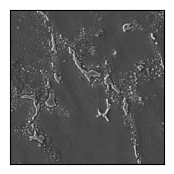

PS13-0500
YS Prediction: 188.01828002929688 ; YS Target: 208.0 ; YS Error%: 9.606595993041992
UTS Prediction: 254.88681030273438 ; UTS Target: 311.0 ; UTS Error%: 18.042827606201172 
E Prediction: 43.47625732421875 ; E Target: 38.0 ; E Error%: 14.411203384399414 
k Prediction: 477.4808044433594 ; k Target: 485.17999267578125 ; k Error%: 1.5868725776672363 
n Prediction: 0.15279559791088104 ; n Target: 0.125 ; n Error%: 22.236478805541992 
---------------------------------------------


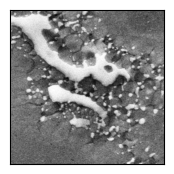

CM06-2000
YS Prediction: 196.53363037109375 ; YS Target: 223.0 ; YS Error%: 11.868327140808105
UTS Prediction: 242.0368194580078 ; UTS Target: 302.0 ; UTS Error%: 19.855358123779297 
E Prediction: 42.130680084228516 ; E Target: 43.0 ; E Error%: 2.021674156188965 
k Prediction: 485.8825988769531 ; k Target: 466.3800048828125 ; k Error%: 4.181695938110352 
n Prediction: 0.1425740122795105 ; n Target: 0.11500000208616257 ; n Error%: 23.977399826049805 
---------------------------------------------


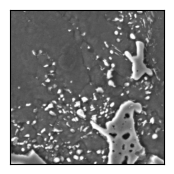

PS13-1500
YS Prediction: 190.26058959960938 ; YS Target: 208.0 ; YS Error%: 8.528562545776367
UTS Prediction: 271.61505126953125 ; UTS Target: 311.0 ; UTS Error%: 12.663970947265625 
E Prediction: 41.60995101928711 ; E Target: 38.0 ; E Error%: 9.499871253967285 
k Prediction: 452.91552734375 ; k Target: 485.17999267578125 ; k Error%: 6.649999141693115 
n Prediction: 0.12708932161331177 ; n Target: 0.125 ; n Error%: 1.671457290649414 
---------------------------------------------


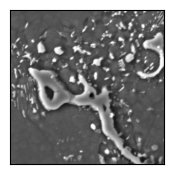

PS13-2000
YS Prediction: 200.88987731933594 ; YS Target: 208.0 ; YS Error%: 3.418328285217285
UTS Prediction: 279.7652893066406 ; UTS Target: 311.0 ; UTS Error%: 10.043315887451172 
E Prediction: 39.711246490478516 ; E Target: 38.0 ; E Error%: 4.503280162811279 
k Prediction: 447.4245910644531 ; k Target: 485.17999267578125 ; k Error%: 7.781730651855469 
n Prediction: 0.11763457953929901 ; n Target: 0.125 ; n Error%: 5.892336368560791 
---------------------------------------------


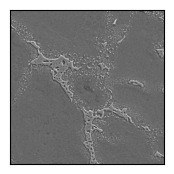

CS06-0500
YS Prediction: 204.07237243652344 ; YS Target: 198.0 ; YS Error%: 3.06685471534729
UTS Prediction: 260.78546142578125 ; UTS Target: 258.0 ; UTS Error%: 1.0796362161636353 
E Prediction: 41.21913528442383 ; E Target: 42.0 ; E Error%: 1.8592016696929932 
k Prediction: 442.85662841796875 ; k Target: 428.760009765625 ; k Error%: 3.287764310836792 
n Prediction: 0.11859297007322311 ; n Target: 0.11999999731779099 ; n Error%: 1.172522783279419 
---------------------------------------------


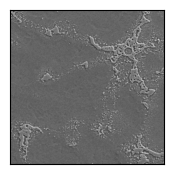

CS06-0500
YS Prediction: 201.26239013671875 ; YS Target: 198.0 ; YS Error%: 1.6476718187332153
UTS Prediction: 257.2073669433594 ; UTS Target: 258.0 ; UTS Error%: 0.3072220981121063 
E Prediction: 40.83516311645508 ; E Target: 42.0 ; E Error%: 2.773421049118042 
k Prediction: 436.5148010253906 ; k Target: 428.760009765625 ; k Error%: 1.8086555004119873 
n Prediction: 0.12028557062149048 ; n Target: 0.11999999731779099 ; n Error%: 0.2379777580499649 
---------------------------------------------


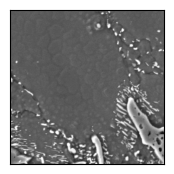

PS13-1500
YS Prediction: 199.1320343017578 ; YS Target: 208.0 ; YS Error%: 4.263444900512695
UTS Prediction: 275.5589294433594 ; UTS Target: 311.0 ; UTS Error%: 11.395842552185059 
E Prediction: 40.47475814819336 ; E Target: 38.0 ; E Error%: 6.512521266937256 
k Prediction: 449.1421203613281 ; k Target: 485.17999267578125 ; k Error%: 7.427732467651367 
n Prediction: 0.12008042633533478 ; n Target: 0.125 ; n Error%: 3.9356589317321777 
---------------------------------------------


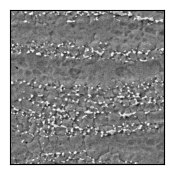

CM06-1000
YS Prediction: 252.14419555664062 ; YS Target: 223.0 ; YS Error%: 13.069145202636719
UTS Prediction: 331.4787902832031 ; UTS Target: 302.0 ; UTS Error%: 9.761188507080078 
E Prediction: 41.90681838989258 ; E Target: 43.0 ; E Error%: 2.542282819747925 
k Prediction: 472.7984313964844 ; k Target: 466.3800048828125 ; k Error%: 1.3762224912643433 
n Prediction: 0.08314528316259384 ; n Target: 0.11500000208616257 ; n Error%: 27.699752807617188 
---------------------------------------------


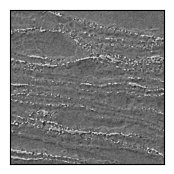

CM06-500
YS Prediction: 213.34915161132812 ; YS Target: 223.0 ; YS Error%: 4.327734470367432
UTS Prediction: 288.8799133300781 ; UTS Target: 302.0 ; UTS Error%: 4.344399452209473 
E Prediction: 46.145328521728516 ; E Target: 43.0 ; E Error%: 7.314717769622803 
k Prediction: 452.18707275390625 ; k Target: 466.3800048828125 ; k Error%: 3.0432119369506836 
n Prediction: 0.12141460925340652 ; n Target: 0.11500000208616257 ; n Error%: 5.5779194831848145 
---------------------------------------------


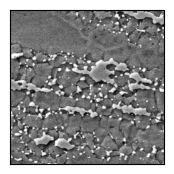

CM06-1500
YS Prediction: 211.8135528564453 ; YS Target: 223.0 ; YS Error%: 5.01634407043457
UTS Prediction: 286.923828125 ; UTS Target: 302.0 ; UTS Error%: 4.992109775543213 
E Prediction: 46.37602615356445 ; E Target: 43.0 ; E Error%: 7.851223468780518 
k Prediction: 452.3766784667969 ; k Target: 466.3800048828125 ; k Error%: 3.0025572776794434 
n Prediction: 0.12496572732925415 ; n Target: 0.11500000208616257 ; n Error%: 8.665847778320312 
---------------------------------------------


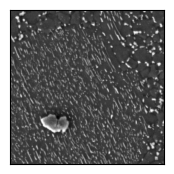

PM03-1500
YS Prediction: 195.8533935546875 ; YS Target: 216.0 ; YS Error%: 9.327132225036621
UTS Prediction: 324.06097412109375 ; UTS Target: 335.0 ; UTS Error%: 3.265380859375 
E Prediction: 46.759666442871094 ; E Target: 49.0 ; E Error%: 4.572109222412109 
k Prediction: 553.4490966796875 ; k Target: 540.6900024414062 ; k Error%: 2.3597798347473145 
n Prediction: 0.16169635951519012 ; n Target: 0.14800000190734863 ; n Error%: 9.254295349121094 
---------------------------------------------


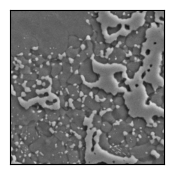

CS06-2000
YS Prediction: 201.62460327148438 ; YS Target: 198.0 ; YS Error%: 1.8306076526641846
UTS Prediction: 282.552978515625 ; UTS Target: 258.0 ; UTS Error%: 9.516658782958984 
E Prediction: 40.39594650268555 ; E Target: 42.0 ; E Error%: 3.8191750049591064 
k Prediction: 450.7587890625 ; k Target: 428.760009765625 ; k Error%: 5.130790710449219 
n Prediction: 0.11800367385149002 ; n Target: 0.11999999731779099 ; n Error%: 1.6636028289794922 
---------------------------------------------


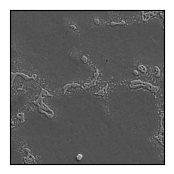

CS06-0500
YS Prediction: 188.2711181640625 ; YS Target: 198.0 ; YS Error%: 4.913576602935791
UTS Prediction: 240.35653686523438 ; UTS Target: 258.0 ; UTS Error%: 6.838551998138428 
E Prediction: 39.35185623168945 ; E Target: 42.0 ; E Error%: 6.3051042556762695 
k Prediction: 420.8777160644531 ; k Target: 428.760009765625 ; k Error%: 1.838392972946167 
n Prediction: 0.1236233338713646 ; n Target: 0.11999999731779099 ; n Error%: 3.0194473266601562 
---------------------------------------------


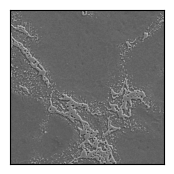

CS06-0500
YS Prediction: 207.70582580566406 ; YS Target: 198.0 ; YS Error%: 4.901932239532471
UTS Prediction: 265.3265686035156 ; UTS Target: 258.0 ; UTS Error%: 2.8397552967071533 
E Prediction: 41.53801727294922 ; E Target: 42.0 ; E Error%: 1.0999587774276733 
k Prediction: 447.5225830078125 ; k Target: 428.760009765625 ; k Error%: 4.3760085105896 
n Prediction: 0.1176217645406723 ; n Target: 0.11999999731779099 ; n Error%: 1.9818607568740845 
---------------------------------------------


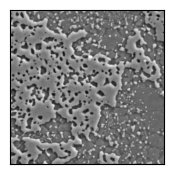

CS06-1500
YS Prediction: 203.59068298339844 ; YS Target: 198.0 ; YS Error%: 2.8235771656036377
UTS Prediction: 262.0031433105469 ; UTS Target: 258.0 ; UTS Error%: 1.5516059398651123 
E Prediction: 41.82746124267578 ; E Target: 42.0 ; E Error%: 0.4108065664768219 
k Prediction: 460.15667724609375 ; k Target: 428.760009765625 ; k Error%: 7.322666645050049 
n Prediction: 0.12247949838638306 ; n Target: 0.11999999731779099 ; n Error%: 2.066250801086426 
---------------------------------------------


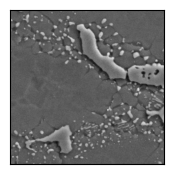

CS06-2000
YS Prediction: 211.2255859375 ; YS Target: 198.0 ; YS Error%: 6.679588317871094
UTS Prediction: 305.80865478515625 ; UTS Target: 258.0 ; UTS Error%: 18.530487060546875 
E Prediction: 44.685726165771484 ; E Target: 42.0 ; E Error%: 6.394586086273193 
k Prediction: 450.7395935058594 ; k Target: 428.760009765625 ; k Error%: 5.12631368637085 
n Prediction: 0.11843351274728775 ; n Target: 0.11999999731779099 ; n Error%: 1.3054038286209106 
---------------------------------------------


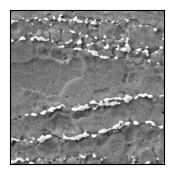

CM06-1500
YS Prediction: 212.1173553466797 ; YS Target: 223.0 ; YS Error%: 4.880109786987305
UTS Prediction: 287.6165771484375 ; UTS Target: 302.0 ; UTS Error%: 4.762722969055176 
E Prediction: 46.33749771118164 ; E Target: 43.0 ; E Error%: 7.761622428894043 
k Prediction: 452.3028869628906 ; k Target: 466.3800048828125 ; k Error%: 3.0183794498443604 
n Prediction: 0.12346730381250381 ; n Target: 0.11500000208616257 ; n Error%: 7.362870693206787 
---------------------------------------------


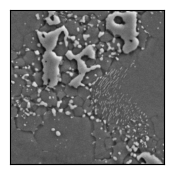

CS06-2000
YS Prediction: 193.2948760986328 ; YS Target: 198.0 ; YS Error%: 2.3763251304626465
UTS Prediction: 260.3515625 ; UTS Target: 258.0 ; UTS Error%: 0.9114583134651184 
E Prediction: 41.333412170410156 ; E Target: 42.0 ; E Error%: 1.5871139764785767 
k Prediction: 445.7237548828125 ; k Target: 428.760009765625 ; k Error%: 3.9564661979675293 
n Prediction: 0.12263915687799454 ; n Target: 0.11999999731779099 ; n Error%: 2.1992995738983154 
---------------------------------------------


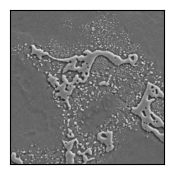

CS06-1000
YS Prediction: 207.98060607910156 ; YS Target: 198.0 ; YS Error%: 5.040709972381592
UTS Prediction: 272.5348815917969 ; UTS Target: 258.0 ; UTS Error%: 5.6336750984191895 
E Prediction: 41.99401092529297 ; E Target: 42.0 ; E Error%: 0.01425970159471035 
k Prediction: 450.50555419921875 ; k Target: 428.760009765625 ; k Error%: 5.071728706359863 
n Prediction: 0.11621374636888504 ; n Target: 0.11999999731779099 ; n Error%: 3.1552090644836426 
---------------------------------------------


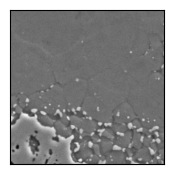

CS06-2000
YS Prediction: 210.9288787841797 ; YS Target: 198.0 ; YS Error%: 6.529736518859863
UTS Prediction: 295.1283264160156 ; UTS Target: 258.0 ; UTS Error%: 14.390824317932129 
E Prediction: 44.29384231567383 ; E Target: 42.0 ; E Error%: 5.46152925491333 
k Prediction: 447.6279602050781 ; k Target: 428.760009765625 ; k Error%: 4.400585651397705 
n Prediction: 0.1124168336391449 ; n Target: 0.11999999731779099 ; n Error%: 6.319303035736084 
---------------------------------------------


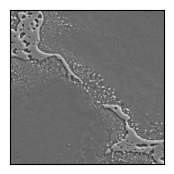

CS06-1000
YS Prediction: 208.31134033203125 ; YS Target: 198.0 ; YS Error%: 5.207747459411621
UTS Prediction: 268.5252990722656 ; UTS Target: 258.0 ; UTS Error%: 4.079573154449463 
E Prediction: 42.24357986450195 ; E Target: 42.0 ; E Error%: 0.5799520611763 
k Prediction: 452.4815979003906 ; k Target: 428.760009765625 ; k Error%: 5.532602787017822 
n Prediction: 0.11827921122312546 ; n Target: 0.11999999731779099 ; n Error%: 1.4339884519577026 
---------------------------------------------


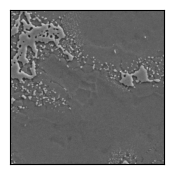

CS06-1000
YS Prediction: 212.9281768798828 ; YS Target: 198.0 ; YS Error%: 7.539483070373535
UTS Prediction: 307.00457763671875 ; UTS Target: 258.0 ; UTS Error%: 18.994022369384766 
E Prediction: 44.75345230102539 ; E Target: 42.0 ; E Error%: 6.5558390617370605 
k Prediction: 454.11907958984375 ; k Target: 428.760009765625 ; k Error%: 5.91451358795166 
n Prediction: 0.12576542794704437 ; n Target: 0.11999999731779099 ; n Error%: 4.804525375366211 
---------------------------------------------


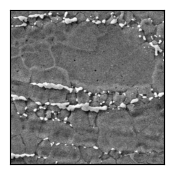

CM06-1500
YS Prediction: 212.8211212158203 ; YS Target: 223.0 ; YS Error%: 4.56451940536499
UTS Prediction: 287.85784912109375 ; UTS Target: 302.0 ; UTS Error%: 4.682831287384033 
E Prediction: 46.33936309814453 ; E Target: 43.0 ; E Error%: 7.765960693359375 
k Prediction: 452.69366455078125 ; k Target: 466.3800048828125 ; k Error%: 2.9345898628234863 
n Prediction: 0.1233309656381607 ; n Target: 0.11500000208616257 ; n Error%: 7.2443156242370605 
---------------------------------------------


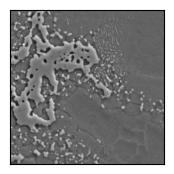

CS06-1500
YS Prediction: 182.73193359375 ; YS Target: 198.0 ; YS Error%: 7.71114444732666
UTS Prediction: 248.66258239746094 ; UTS Target: 258.0 ; UTS Error%: 3.619154214859009 
E Prediction: 40.902366638183594 ; E Target: 42.0 ; E Error%: 2.613412857055664 
k Prediction: 446.0368347167969 ; k Target: 428.760009765625 ; k Error%: 4.029486179351807 
n Prediction: 0.1377430409193039 ; n Target: 0.11999999731779099 ; n Error%: 14.785869598388672 
---------------------------------------------


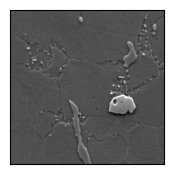

CS04-1000
YS Prediction: 164.10716247558594 ; YS Target: 148.0 ; YS Error%: 10.883217811584473
UTS Prediction: 224.95196533203125 ; UTS Target: 210.0 ; UTS Error%: 7.119983673095703 
E Prediction: 39.53825378417969 ; E Target: 37.0 ; E Error%: 6.860145092010498 
k Prediction: 403.78546142578125 ; k Target: 365.45001220703125 ; k Error%: 10.48992919921875 
n Prediction: 0.1500292718410492 ; n Target: 0.14300000667572021 ; n Error%: 4.91556978225708 
---------------------------------------------


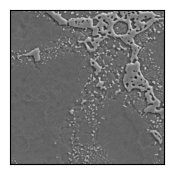

CS06-1000
YS Prediction: 208.3229522705078 ; YS Target: 198.0 ; YS Error%: 5.2136125564575195
UTS Prediction: 303.7525634765625 ; UTS Target: 258.0 ; UTS Error%: 17.733551025390625 
E Prediction: 43.234283447265625 ; E Target: 42.0 ; E Error%: 2.938770055770874 
k Prediction: 460.746337890625 ; k Target: 428.760009765625 ; k Error%: 7.460194110870361 
n Prediction: 0.1259365826845169 ; n Target: 0.11999999731779099 ; n Error%: 4.947154521942139 
---------------------------------------------


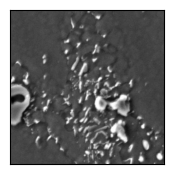

PS13-2000
YS Prediction: 172.2037811279297 ; YS Target: 208.0 ; YS Error%: 17.209720611572266
UTS Prediction: 264.31689453125 ; UTS Target: 311.0 ; UTS Error%: 15.010644912719727 
E Prediction: 45.93986892700195 ; E Target: 38.0 ; E Error%: 20.894392013549805 
k Prediction: 487.75164794921875 ; k Target: 485.17999267578125 ; k Error%: 0.5300414562225342 
n Prediction: 0.15603280067443848 ; n Target: 0.125 ; n Error%: 24.82624053955078 
---------------------------------------------


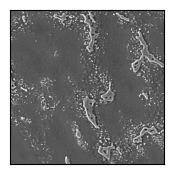

PS13-0500
YS Prediction: 185.83364868164062 ; YS Target: 208.0 ; YS Error%: 10.656900405883789
UTS Prediction: 259.7439270019531 ; UTS Target: 311.0 ; UTS Error%: 16.48105239868164 
E Prediction: 46.60094451904297 ; E Target: 38.0 ; E Error%: 22.634065628051758 
k Prediction: 511.0921630859375 ; k Target: 485.17999267578125 ; k Error%: 5.340733528137207 
n Prediction: 0.16194523870944977 ; n Target: 0.125 ; n Error%: 29.556190490722656 
---------------------------------------------
avg YS error: 8.98650074005127
avg UTS error: 6.370344638824463
avg K error: 4.4553632736206055
avg n error: 8.641984939575195


In [6]:
#Class-Out Validation
print("Class-Out Validation")
load_dir = '/kaggle/input/mic-mech3-checkpoint/Mic-Mech-Over-Best800.pth.tar'
load_model(load_dir)
model.eval()
with torch.no_grad():    

        test_iter = next(iter(class_out_test_loader))
        test_images, test_labels = test_iter
        test_images = aug_transform(test_images)
        test_images = test_images.to(device)
        t_mag, t_ys, t_uts, t_el, t_e, t_k, t_n = class_maker(batch_size = test_labels.size(0), labels = test_labels, tab = class_out_table)
        t_mag = t_mag.long().to(device)
        t_ys = t_ys.float().to(device)
        t_uts = t_uts.float().to(device)
        t_el = t_el.float().to(device)
        t_e = t_e.float().to(device)
        t_k = t_k.float().to(device)
        t_n = t_n.float().to(device)
        test_predictions = ema_model(test_images, t_mag)
        
        summY = 0
        summU = 0
        summK = 0
        summN = 0
        for i in range(len(test_images)):
            show_grids(test_images[i])
            print(class_out_label[test_labels[i].item()])
            print(f'YS Prediction: {test_predictions[i,0]} ; YS Target: {t_ys[i]} ; YS Error%: {(abs(test_predictions[i,0]-t_ys[i])/t_ys[i])*100}' )
            summY += (abs(test_predictions[i,0]-t_ys[i])/t_ys[i])*100
            summU += (abs(test_predictions[i,1]-t_uts[i])/t_uts[i])*100
            summK += (abs(test_predictions[i,4]-t_k[i])/t_k[i])*100
            summN += (abs(test_predictions[i,5]-t_n[i])/t_n[i])*100
            print(f'UTS Prediction: {test_predictions[i,1]} ; UTS Target: {t_uts[i]} ; UTS Error%: {(abs(test_predictions[i,1]-t_uts[i])/t_uts[i])*100} ')
            print(f'E Prediction: {test_predictions[i,3]} ; E Target: {t_e[i]} ; E Error%: {(abs(test_predictions[i,3]-t_e[i])/t_e[i])*100} ')
            print(f'k Prediction: {test_predictions[i,4]} ; k Target: {t_k[i]} ; k Error%: {(abs(test_predictions[i,4]-t_k[i])/t_k[i])*100} ')
            print(f'n Prediction: {test_predictions[i,5]} ; n Target: {t_n[i]} ; n Error%: {(abs(test_predictions[i,5]-t_n[i])/t_n[i])*100} ')
            print('---------------------------------------------')
            
print(f'avg YS error: {summU/len(test_images)}')
print(f'avg UTS error: {summY/len(test_images)}')
print(f'avg K error: {summK/len(test_images)}')
print(f'avg n error: {summN/len(test_images)}')